In [5]:
# Install LightGBM
!pip install lightgbm

# Install other required libraries (optional since pandas, sklearn, and numpy are pre-installed in Colab)
!pip install pandas scikit-learn


In [6]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [7]:
data_path = 'balanced_training_data.csv'
df = pd.read_csv(data_path)


In [8]:
  # Step 1: Install Required Libraries
  !pip install --upgrade lightgbm
  !pip install pandas scikit-learn

  # Step 2: Import Libraries
  import pandas as pd
  import lightgbm as lgb
  from sklearn.model_selection import train_test_split
  from sklearn.metrics import classification_report, roc_auc_score

  # Step 3: Load the Dataset
  data_path = 'balanced_training_data.csv'  # Adjust the path if needed
  df = pd.read_csv(data_path)

  # Step 4: Handle Missing Values
  print("Checking for missing values:")
  print(df.isnull().sum())

  # Drop rows where SepsisLabel is NaN
  df = df.dropna(subset=['SepsisLabel'])

  # Fill remaining NaN values in features with column means
  df = df.fillna(df.mean())

  # Step 5: Prepare Features (X) and Target (y)
  X = df.drop(columns=['SepsisLabel'])
  y = df['SepsisLabel']

  # Step 6: Split Data into Training and Testing Sets
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Step 7: Define LightGBM Parameters
  params = {
      'objective': 'binary',        # Binary classification
      'metric': 'auc',              # Evaluation metric: AUC
      'boosting_type': 'gbdt',      # Gradient Boosting Decision Tree
      'learning_rate': 0.05,        # Learning rate
      'num_leaves': 31,             # Maximum number of leaves in one tree
      'max_depth': -1,              # Maximum depth of the tree (-1 means no limit)
      'feature_fraction': 0.8,      # Fraction of features used per iteration
      'bagging_fraction': 0.8,      # Subsample ratio of the training instance
      'bagging_freq': 5,            # Frequency of bagging
      'verbose': -1                 # Suppress LightGBM warnings
  }

  # Step 8: Create LightGBM Datasets
  train_data = lgb.Dataset(X_train, label=y_train)
  test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

  # Step 9: Train the LightGBM Model with Callbacks
  lgb_model = lgb.train(
      params,
      train_data,
      num_boost_round=1000,
      valid_sets=[train_data, test_data],  # Training and validation sets
      valid_names=['train', 'test'],      # Names of datasets
      callbacks=[lgb.early_stopping(stopping_rounds=50),  # Early stopping callback
                lgb.log_evaluation(period=100)]          # Log evaluation every 100 rounds
  )

  # Step 10: Make Predictions
  y_pred = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)
  y_pred_binary = (y_pred > 0.5).astype(int)

  # Step 11: Evaluate the Model
  print("LightGBM Classification Report:")
  print(classification_report(y_test, y_pred_binary))
  print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))


Checking for missing values:
HR                  0
O2Sat               0
Temp                0
SBP                 0
MAP                 0
DBP                 0
Resp                0
BaseExcess          0
HCO3                0
FiO2                0
pH                  0
PaCO2               0
SaO2                0
AST                 0
BUN                 0
Alkalinephos        0
Calcium             0
Chloride            0
Creatinine          0
Bilirubin_direct    0
Glucose             0
Lactate             0
Magnesium           0
Phosphate           0
Potassium           1
Bilirubin_total     1
TroponinI           1
Hct                 1
Hgb                 1
PTT                 1
WBC                 1
Fibrinogen          1
Platelets           1
Age                 1
Gender              1
HospAdmTime         1
ICULOS              1
SepsisLabel         1
dtype: int64
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.907514	test's auc: 0.899447
[200]	train'

In [11]:
# Import necessary libraries
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

# CatBoost Training
print("\nTraining CatBoost...")
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=50,
    early_stopping_rounds=50
)

catboost_model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# CatBoost Predictions and Evaluation
y_pred_cat = catboost_model.predict_proba(X_test)[:, 1]
y_pred_cat_binary = (y_pred_cat > 0.5).astype(int)

print("\nCatBoost Classification Report:")
print(classification_report(y_test, y_pred_cat_binary))
print("CatBoost ROC-AUC Score:", roc_auc_score(y_test, y_pred_cat))


Training CatBoost...
0:	test: 0.7900203	best: 0.7900203 (0)	total: 81.2ms	remaining: 1m 21s
50:	test: 0.8505588	best: 0.8505588 (50)	total: 1.65s	remaining: 30.7s
100:	test: 0.8661250	best: 0.8661250 (100)	total: 3.23s	remaining: 28.8s
150:	test: 0.8768189	best: 0.8768189 (150)	total: 5.29s	remaining: 29.7s
200:	test: 0.8863867	best: 0.8863867 (200)	total: 8s	remaining: 31.8s
250:	test: 0.8945702	best: 0.8945702 (250)	total: 9.52s	remaining: 28.4s
300:	test: 0.9026146	best: 0.9026146 (300)	total: 11s	remaining: 25.7s
350:	test: 0.9101467	best: 0.9101467 (350)	total: 12.6s	remaining: 23.3s
400:	test: 0.9162712	best: 0.9162712 (400)	total: 14.2s	remaining: 21.1s
450:	test: 0.9218961	best: 0.9218961 (450)	total: 16.2s	remaining: 19.8s
500:	test: 0.9270176	best: 0.9270176 (500)	total: 18.3s	remaining: 18.2s
550:	test: 0.9316322	best: 0.9316322 (550)	total: 22.8s	remaining: 18.5s
600:	test: 0.9361958	best: 0.9361958 (600)	total: 26.3s	remaining: 17.5s
650:	test: 0.9399650	best: 0.9399650 (

In [10]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.6 MB/s eta 0:00:00


In [23]:
!pip install xgboost


In [12]:
# Step 1: Install Required Libraries
!pip install xgboost
!pip install pandas scikit-learn

# Step 2: Import Libraries
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Step 3: Load the Dataset
data_path = 'balanced_training_data.csv'  # Adjust the path if needed
df = pd.read_csv(data_path)

# Step 4: Handle Missing Values
print("Checking for missing values:")
print(df.isnull().sum())

# Drop rows where the target column 'SepsisLabel' is NaN
df = df.dropna(subset=['SepsisLabel'])

# Fill missing values in numeric columns with their mean
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Fill missing values in non-numeric columns with a placeholder or mode
non_numeric_columns = df.select_dtypes(exclude=['number']).columns
df[non_numeric_columns] = df[non_numeric_columns].fillna('Unknown')

# Verify missing values
print("Missing values after handling:")
print(df.isnull().sum())

# Step 5: Prepare Features (X) and Target (y)
X = df.drop(columns=['SepsisLabel'])
y = df['SepsisLabel']

# Step 6: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Convert Data to DMatrix (Optimized Data Structure for XGBoost)
train_dmatrix = xgb.DMatrix(X_train, label=y_train)
test_dmatrix = xgb.DMatrix(X_test, label=y_test)

# Step 8: Define XGBoost Parameters
params = {
    'objective': 'binary:logistic',  # Binary classification
    'eval_metric': 'auc',           # Evaluation metric: AUC
    'learning_rate': 0.05,          # Learning rate
    'max_depth': 6,                 # Maximum depth of the tree
    'min_child_weight': 1,          # Minimum sum of weights of all child nodes
    'subsample': 0.8,               # Subsample ratio of the training instance
    'colsample_bytree': 0.8,        # Subsample ratio of columns when constructing each tree
    'seed': 42                      # Random seed for reproducibility
}

# Step 9: Train the XGBoost Model
evals = [(train_dmatrix, 'train'), (test_dmatrix, 'test')]  # Evaluation sets
xgb_model = xgb.train(
    params,
    train_dmatrix,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,  # Early stopping based on validation AUC
    verbose_eval=100           # Log every 100 iterations
)

# Step 10: Make Predictions
y_pred = xgb_model.predict(test_dmatrix)
y_pred_binary = (y_pred > 0.5).astype(int)

# Step 11: Evaluate the Model
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_binary))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))


Checking for missing values:
HR                  0
O2Sat               0
Temp                0
SBP                 0
MAP                 0
DBP                 0
Resp                0
BaseExcess          0
HCO3                0
FiO2                0
pH                  0
PaCO2               0
SaO2                0
AST                 0
BUN                 0
Alkalinephos        0
Calcium             0
Chloride            0
Creatinine          0
Bilirubin_direct    0
Glucose             0
Lactate             0
Magnesium           0
Phosphate           0
Potassium           0
Bilirubin_total     0
TroponinI           0
Hct                 0
Hgb                 0
PTT                 0
WBC                 1
Fibrinogen          1
Platelets           1
Age                 1
Gender              1
HospAdmTime         1
ICULOS              1
SepsisLabel         1
dtype: int64
Missing values after handling:
HR                  0
O2Sat               0
Temp                0
SBP                 0
MAP

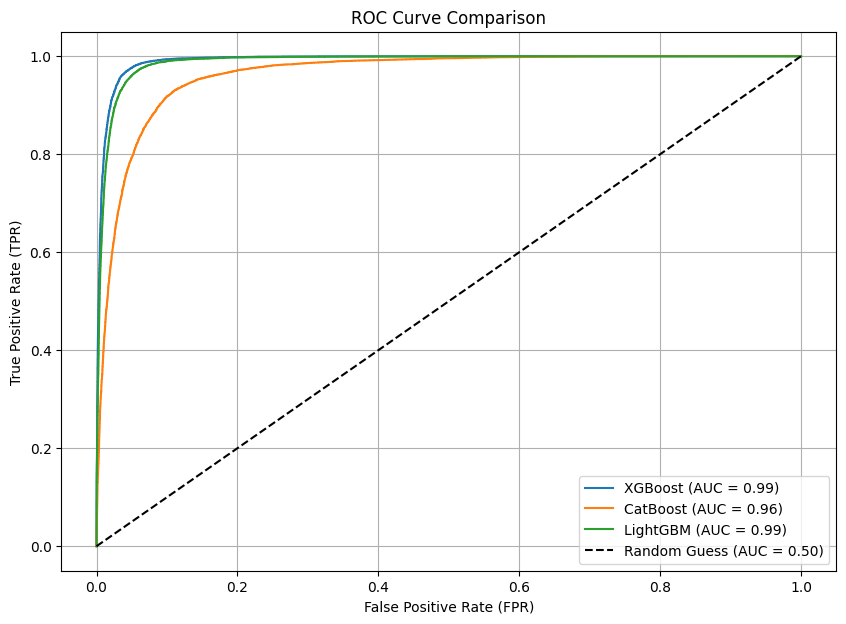

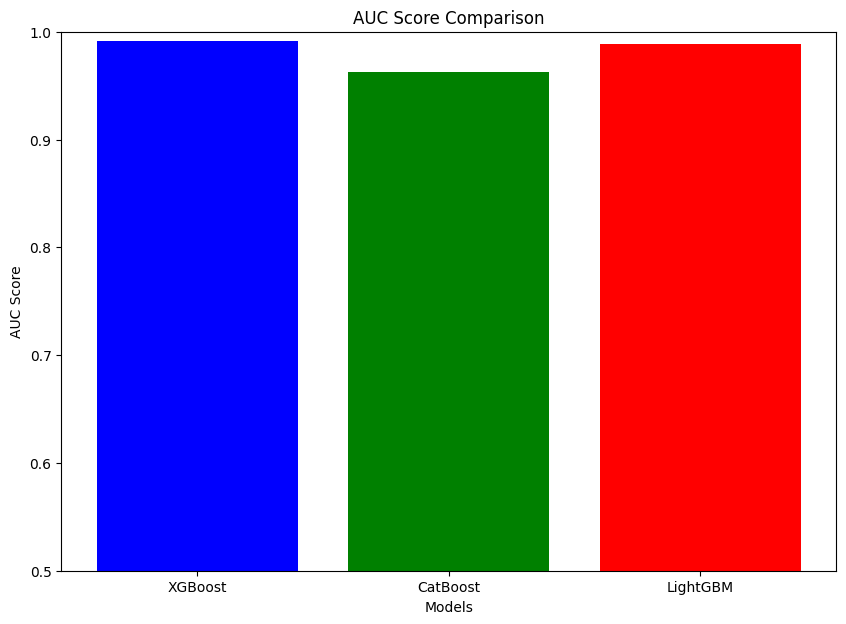

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# Step 1: Get Predictions (Replace these with your actual models' predictions)
# XGBoost Predictions
y_pred_xgb = xgb_model.predict(test_dmatrix)

# CatBoost Predictions
y_pred_cat = catboost_model.predict_proba(X_test)[:, 1]

# LightGBM Predictions
y_pred_lgb = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

# Step 2: Compute ROC and AUC for each model
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_xgb)

fpr_cat, tpr_cat, _ = roc_curve(y_test, y_pred_cat)
auc_cat = roc_auc_score(y_test, y_pred_cat)

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_lgb)
auc_lgb = roc_auc_score(y_test, y_pred_lgb)

# Step 3: Plot the ROC Curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.2f})')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()
plt.grid()
plt.show()

# Step 4: Bar Chart of AUC Scores
model_names = ['XGBoost', 'CatBoost', 'LightGBM']
auc_scores = [auc_xgb, auc_cat, auc_lgb]

plt.figure(figsize=(10, 7))
plt.bar(model_names, auc_scores, color=['blue', 'green', 'red'])
plt.title('AUC Score Comparison')
plt.xlabel('Models')
plt.ylabel('AUC Score')
plt.ylim(0.5, 1.0)
plt.show()


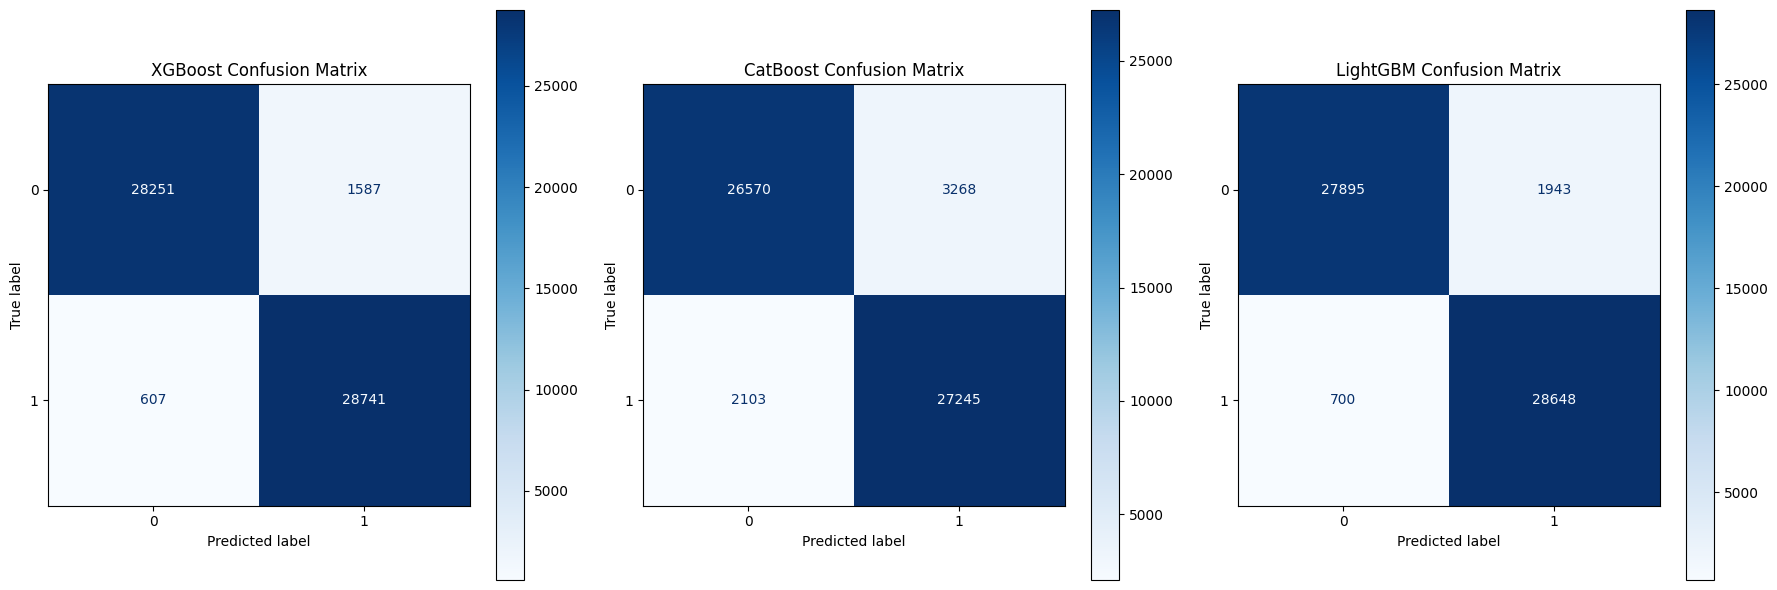

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate binary predictions for each model
y_pred_xgb_binary = (xgb_model.predict(test_dmatrix) > 0.5).astype(int)
y_pred_cat_binary = (catboost_model.predict_proba(X_test)[:, 1] > 0.5).astype(int)
y_pred_lgb_binary = (lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration) > 0.5).astype(int)

# Plot confusion matrix for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, model_name, y_pred_binary in zip(axes, ['XGBoost', 'CatBoost', 'LightGBM'],
                                         [y_pred_xgb_binary, y_pred_cat_binary, y_pred_lgb_binary]):
    cm = confusion_matrix(y_test, y_pred_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'{model_name} Confusion Matrix')

plt.tight_layout()
plt.show()


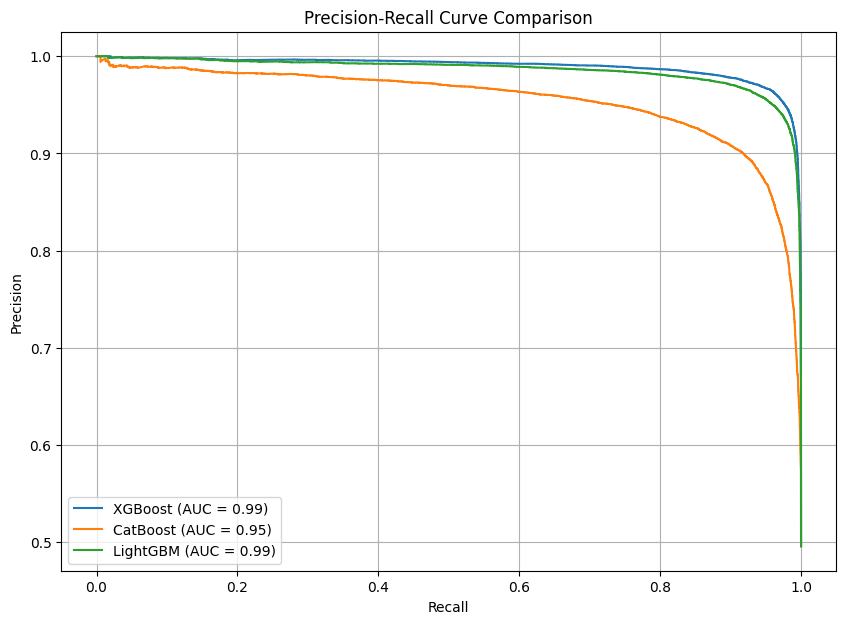

In [15]:
from sklearn.metrics import precision_recall_curve, auc

# Compute precision-recall curves and AUC for each model
prec_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_model.predict(test_dmatrix))
pr_auc_xgb = auc(recall_xgb, prec_xgb)

prec_cat, recall_cat, _ = precision_recall_curve(y_test, catboost_model.predict_proba(X_test)[:, 1])
pr_auc_cat = auc(recall_cat, prec_cat)

prec_lgb, recall_lgb, _ = precision_recall_curve(y_test, lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration))
pr_auc_lgb = auc(recall_lgb, prec_lgb)

# Plot precision-recall curves
plt.figure(figsize=(10, 7))
plt.plot(recall_xgb, prec_xgb, label=f'XGBoost (AUC = {pr_auc_xgb:.2f})')
plt.plot(recall_cat, prec_cat, label=f'CatBoost (AUC = {pr_auc_cat:.2f})')
plt.plot(recall_lgb, prec_lgb, label=f'LightGBM (AUC = {pr_auc_lgb:.2f})')

plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()


<Figure size 1000x700 with 0 Axes>

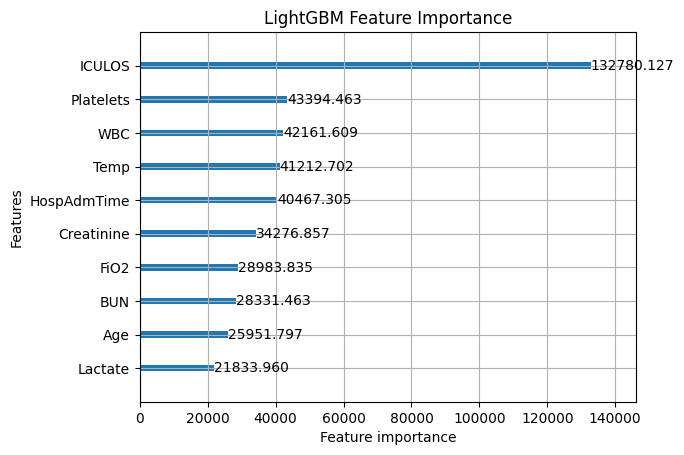

In [18]:
plt.figure(figsize=(10, 7))
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='gain')
plt.title('LightGBM Feature Importance')
plt.show()


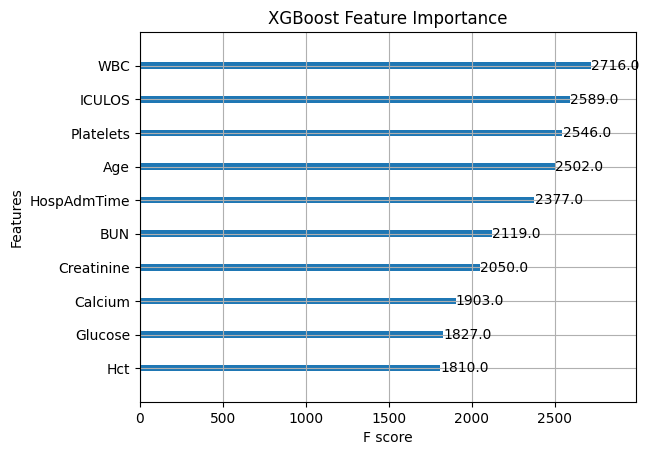

In [19]:
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='weight', title='XGBoost Feature Importance')
plt.show()


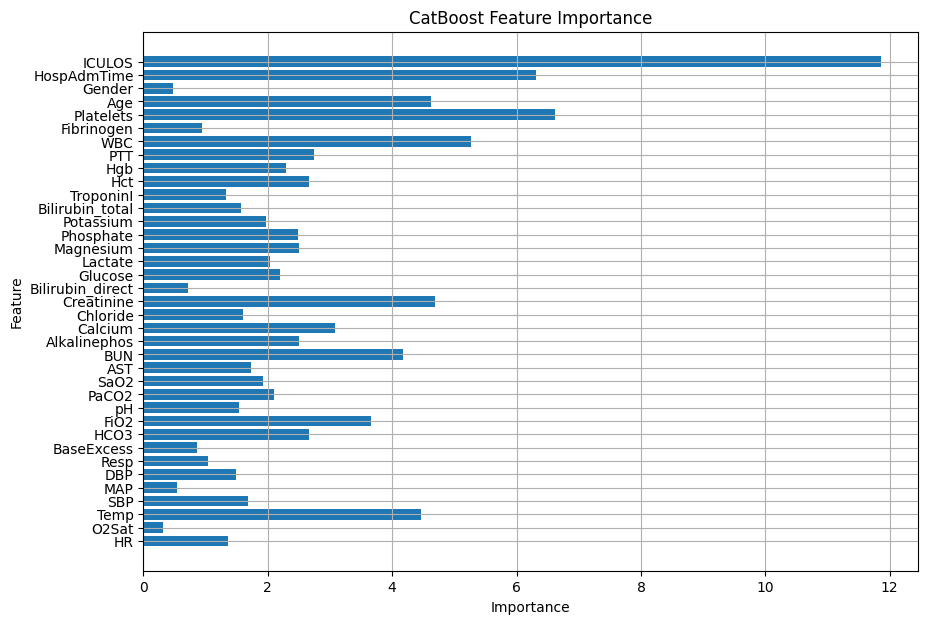

In [20]:
feature_importances = catboost_model.get_feature_importance()
feature_names = X_train.columns

# Plot CatBoost feature importance
plt.figure(figsize=(10, 7))
plt.barh(feature_names, feature_importances)
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid()
plt.show()


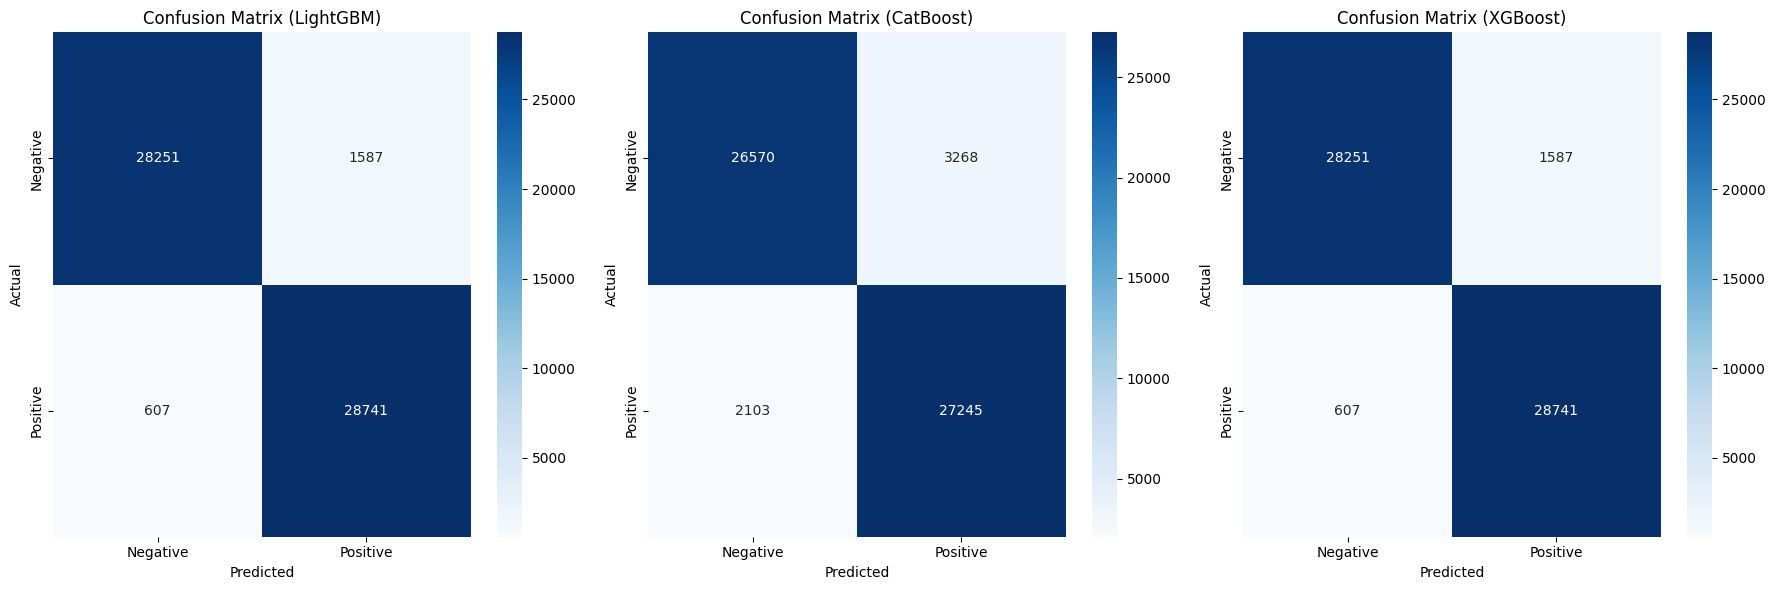

In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrices
cm_lgb = confusion_matrix(y_test, (y_pred > 0.5).astype(int))  # LightGBM
cm_cat = confusion_matrix(y_test, (y_pred_cat > 0.5).astype(int))  # CatBoost
cm_xgb = confusion_matrix(y_test, (y_pred_xgb > 0.5).astype(int))  # XGBoost

# Plot confusion matrices
models = ['LightGBM', 'CatBoost', 'XGBoost']
cms = [cm_lgb, cm_cat, cm_xgb]

plt.figure(figsize=(18, 6))
for i, (model, cm) in enumerate(zip(models, cms), 1):
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix ({model})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()


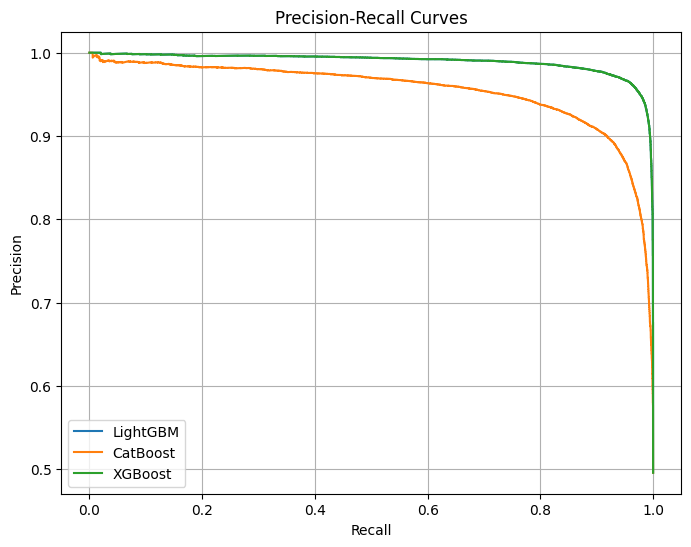

In [43]:
from sklearn.metrics import precision_recall_curve

# Generate precision-recall values
precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, y_pred)  # LightGBM
precision_cat, recall_cat, _ = precision_recall_curve(y_test, y_pred_cat)  # CatBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_xgb)  # XGBoost

# Plot precision-recall curves
plt.figure(figsize=(8, 6))
plt.plot(recall_lgb, precision_lgb, label='LightGBM')
plt.plot(recall_cat, precision_cat, label='CatBoost')
plt.plot(recall_xgb, precision_xgb, label='XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid()
plt.show()


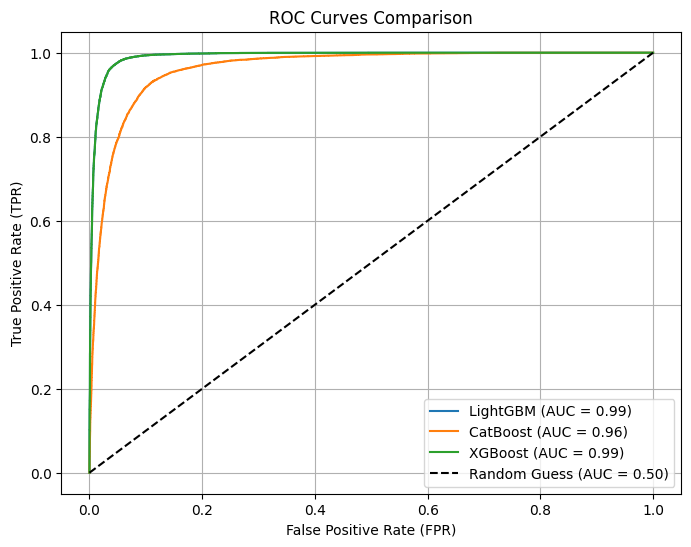

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

# Generate ROC values
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred)  # LightGBM
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_pred_cat)  # CatBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)  # XGBoost

# AUC scores
auc_lgb = roc_auc_score(y_test, y_pred)
auc_cat = roc_auc_score(y_test, y_pred_cat)
auc_xgb = roc_auc_score(y_test, y_pred_xgb)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.2f})')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')
plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()
plt.grid()
plt.show()


<Figure size 1000x600 with 0 Axes>

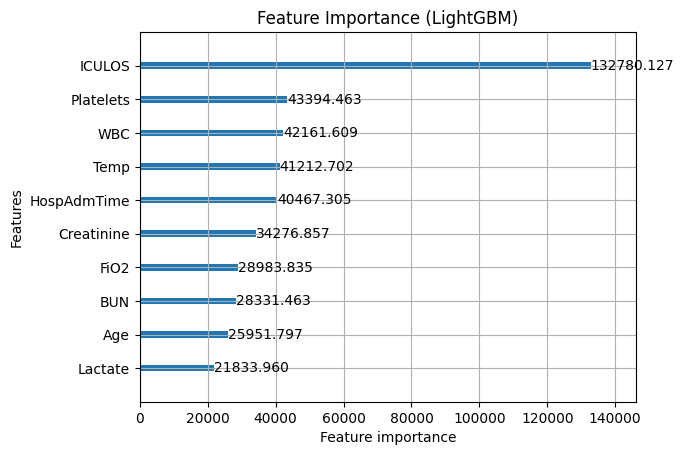

<ipython-input-45-c168b77c7bed>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_feature_importance['Importances'], y=cat_feature_importance['Feature Id'], palette='viridis')


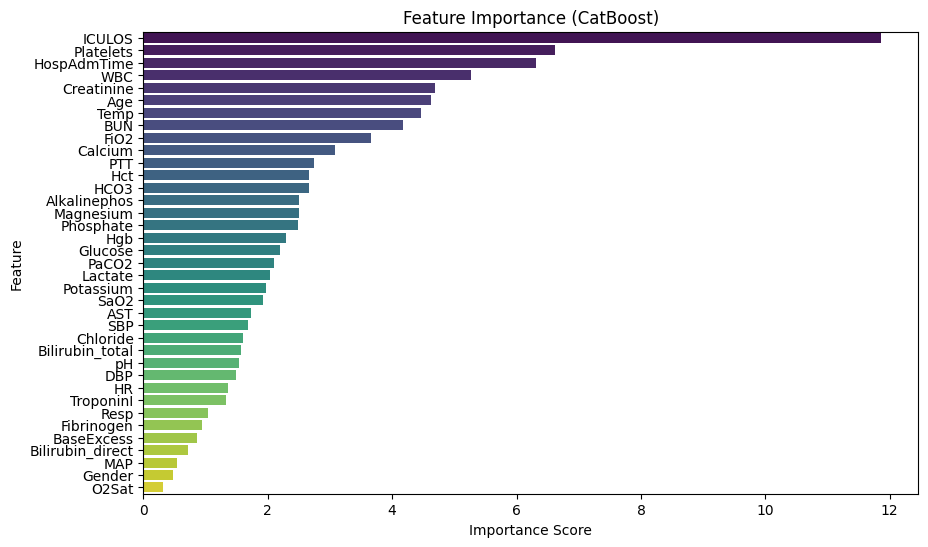

<Figure size 1000x600 with 0 Axes>

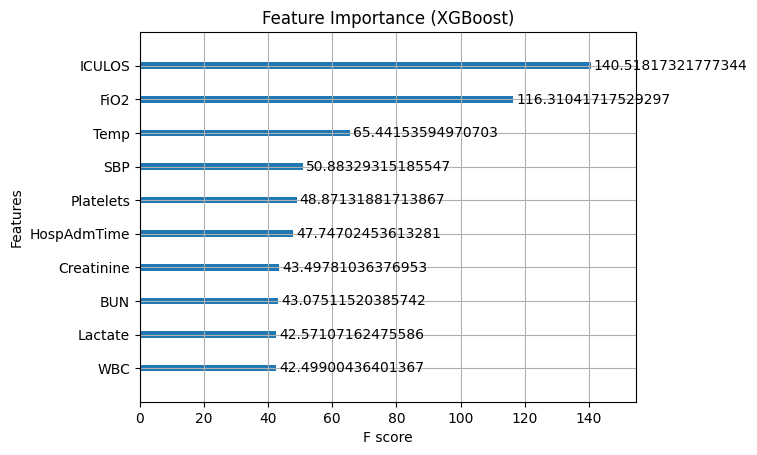

In [45]:
# LightGBM Feature Importance
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='gain', title='Feature Importance (LightGBM)')
plt.show()

# CatBoost Feature Importance
cat_feature_importance = catboost_model.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
sns.barplot(x=cat_feature_importance['Importances'], y=cat_feature_importance['Feature Id'], palette='viridis')
plt.title('Feature Importance (CatBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# XGBoost Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='gain', title='Feature Importance (XGBoost)')
plt.show()


<ipython-input-47-35910d1138e1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=auc_scores, palette='muted')


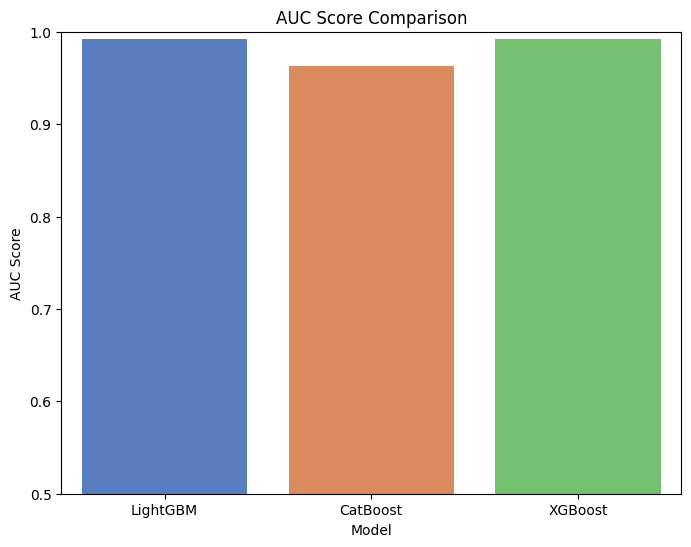

In [47]:
# Compare AUC Scores for all models
model_names = ['LightGBM', 'CatBoost', 'XGBoost']
auc_scores = [auc_lgb, auc_cat, auc_xgb]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=auc_scores, palette='muted')
plt.title('AUC Score Comparison')
plt.xlabel('Model')
plt.ylabel('AUC Score')
plt.ylim(0.5, 1.0)
plt.show()


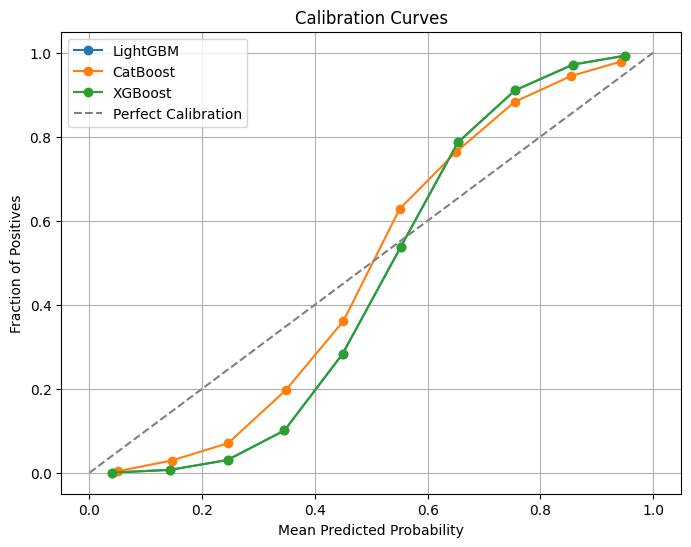

In [48]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Generate calibration curves
prob_true_lgb, prob_pred_lgb = calibration_curve(y_test, y_pred, n_bins=10)  # LightGBM
prob_true_cat, prob_pred_cat = calibration_curve(y_test, y_pred_cat, n_bins=10)  # CatBoost
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, y_pred_xgb, n_bins=10)  # XGBoost

# Plot calibration curves
plt.figure(figsize=(8, 6))
plt.plot(prob_pred_lgb, prob_true_lgb, marker='o', label='LightGBM')
plt.plot(prob_pred_cat, prob_true_cat, marker='o', label='CatBoost')
plt.plot(prob_pred_xgb, prob_true_xgb, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves')
plt.legend()
plt.grid()
plt.show()


In [23]:
!pip install PyPDF2
!pip install lightgbm xgboost catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.7 MB/s eta 0:00:00


In [26]:
def prepare_model_input(features, feature_columns):
    """
    Prepare the input DataFrame for prediction.

    Args:
        features (dict): Extracted features from the PDF text.
        feature_columns (list): List of feature names expected by the model.

    Returns:
        pd.DataFrame: Single-row DataFrame ready for prediction.
    """
    # Initialize input with default values
    input_data = {col: 0.0 for col in feature_columns}

    # Map extracted features to the input
    for feature, value in features.items():
        if feature == 'Gender':
            input_data[feature] = 1.0 if value == 'Female' else 0.0  # Encode Gender: Male=0, Female=1
        elif feature in input_data:
            input_data[feature] = value if value is not None else 0.0  # Handle missing values

    # Return as DataFrame
    return pd.DataFrame([input_data])


In [27]:
models = {
    'LightGBM': lgb_model,
    'CatBoost': catboost_model,
    'XGBoost': xgb_model
}


In [30]:
# Define the models (Replace with your actual trained models)
models = {
    'LightGBM': lgb_model,  # Your trained LightGBM model
    'CatBoost': catboost_model,  # Your trained CatBoost model
    'XGBoost': xgb_model  # Your trained XGBoost model
}

# Feature columns expected by the models
feature_columns = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'BaseExcess', 'HCO3', 'FiO2',
    'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride',
    'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
    'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
    'Fibrinogen', 'Platelets', 'Age', 'Gender', 'HospAdmTime', 'ICULOS'
]

# Example PDF file path
pdf_file_path = "Enhanced_Medical_Report_1.pdf"

# Run the function to predict sepsis and display results
predictions = predict_sepsis_from_pdf_with_display(pdf_file_path, models, feature_columns)


NameError: name 'predict_sepsis_from_pdf_with_display' is not defined

In [28]:
# Example PDF file path
pdf_file_path = "Enhanced_Medical_Report_1.pdf"

# Predict sepsis from the PDF
predictions = predict_sepsis_from_pdf(pdf_file_path, models, feature_columns)

# Display results
print("Predictions from the PDF:")
for model, score in predictions.items():
    print(f"{model}: Probability of Sepsis = {score:.2f}")


Predictions from the PDF:
LightGBM: Probability of Sepsis = 0.90
CatBoost: Probability of Sepsis = 0.78
XGBoost: Probability of Sepsis = 0.94


In [32]:
import PyPDF2
import re
import pandas as pd
from tabulate import tabulate

# Function to extract text from PDF
def extract_text_from_pdf(pdf_path):
    with open(pdf_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        text = ""
        for page in reader.pages:
            text += page.extract_text()
    return text

# Function to parse features from the text
def parse_features_from_text(text):
    feature_patterns = {
        'HR': r'HR:\s*(\d+(\.\d+)?)',
        'Temp': r'Temp:\s*(\d+(\.\d+)?)',
        'SBP': r'SBP:\s*(\d+(\.\d+)?)',
        'MAP': r'MAP:\s*(\d+(\.\d+)?)',
        'DBP': r'DBP:\s*(\d+(\.\d+)?)',
        'Resp': r'Resp:\s*(\d+(\.\d+)?)',
        'Age': r'Age:\s*(\d+)',
        'Gender': r'Gender:\s*(\w+)',
        'Lactate': r'Lactate:\s*(\d+(\.\d+)?)',
        'Glucose': r'Glucose:\s*(\d+(\.\d+)?)'
    }
    extracted_features = {}
    for feature, pattern in feature_patterns.items():
        match = re.search(pattern, text)
        if match:
            extracted_features[feature] = float(match.group(1)) if feature != 'Gender' else match.group(1)
        else:
            extracted_features[feature] = None
    return extracted_features

# Function to prepare model input
def prepare_model_input(features, feature_columns):
    input_data = {col: 0.0 for col in feature_columns}
    for feature, value in features.items():
        if feature == 'Gender':
            input_data[feature] = 1.0 if value == 'Female' else 0.0
        elif feature in input_data:
            input_data[feature] = value if value is not None else 0.0
    return pd.DataFrame([input_data])

# Function to predict sepsis and display results
def predict_sepsis_from_pdf_with_display(pdf_path, models, feature_columns):
    text = extract_text_from_pdf(pdf_path)
    features = parse_features_from_text(text)

    # Display extracted features
    extracted_features_table = [[feature, value] for feature, value in features.items()]
    print("\nExtracted Features:")
    print(tabulate(extracted_features_table, headers=["Feature", "Value"], tablefmt="grid"))

    input_data = prepare_model_input(features, feature_columns)

    predictions = {
        'LightGBM': models['LightGBM'].predict(input_data)[0],
        'CatBoost': models['CatBoost'].predict_proba(input_data)[:, 1][0],
        'XGBoost': models['XGBoost'].predict(xgb.DMatrix(input_data))[0]
    }

    # Display predictions
    predictions_table = [[model, f"{score:.2f}"] for model, score in predictions.items()]
    print("\nPrediction Results:")
    print(tabulate(predictions_table, headers=["Model", "Probability of Sepsis"], tablefmt="grid"))

    return predictions

# Define trained models (replace these with your actual trained models)
models = {
    'LightGBM': lgb_model,      # Replace with your trained LightGBM model
    'CatBoost': catboost_model, # Replace with your trained CatBoost model
    'XGBoost': xgb_model        # Replace with your trained XGBoost model
}

# Feature columns expected by the model
feature_columns = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'BaseExcess', 'HCO3', 'FiO2',
    'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride',
    'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
    'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
    'Fibrinogen', 'Platelets', 'Age', 'Gender', 'HospAdmTime', 'ICULOS'
]

# Example PDF file path
pdf_file_path = "Enhanced_Medical_Report_1.pdf"

# Run prediction and display results
predictions = predict_sepsis_from_pdf_with_display(pdf_file_path, models, feature_columns)



Extracted Features:
+-----------+---------+
| Feature   | Value   |
+===========+=========+
| HR        | 94.87   |
+-----------+---------+
| Temp      | 37.78   |
+-----------+---------+
| SBP       | 175.31  |
+-----------+---------+
| MAP       | 94.5    |
+-----------+---------+
| DBP       | 99.1    |
+-----------+---------+
| Resp      | 27.9    |
+-----------+---------+
| Age       | 18.0    |
+-----------+---------+
| Gender    | Female  |
+-----------+---------+
| Lactate   | 3.15    |
+-----------+---------+
| Glucose   | 97.88   |
+-----------+---------+

Prediction Results:
+----------+-------------------------+
| Model    |   Probability of Sepsis |
+==========+=========================+
| LightGBM |                    0.9  |
+----------+-------------------------+
| CatBoost |                    0.78 |
+----------+-------------------------+
| XGBoost  |                    0.94 |
+----------+-------------------------+


In [40]:
import PyPDF2
import re
import pandas as pd
from tabulate import tabulate
from IPython.display import display
import ipywidgets as widgets

# Function to extract text from PDF
def extract_text_from_pdf(pdf_path):
    with open(pdf_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        text = ""
        for page in reader.pages:
            text += page.extract_text()
    return text

# Function to parse features from the text
def parse_features_from_text(text):
    feature_patterns = {
        'HR': r'HR:\s*(\d+(\.\d+)?)',
        'Temp': r'Temp:\s*(\d+(\.\d+)?)',
        'SBP': r'SBP:\s*(\d+(\.\d+)?)',
        'MAP': r'MAP:\s*(\d+(\.\d+)?)',
        'DBP': r'DBP:\s*(\d+(\.\d+)?)',
        'Resp': r'Resp:\s*(\d+(\.\d+)?)',
        'Age': r'Age:\s*(\d+)',
        'Gender': r'Gender:\s*(\w+)',
        'Lactate': r'Lactate:\s*(\d+(\.\d+)?)',
        'Glucose': r'Glucose:\s*(\d+(\.\d+)?)'
    }
    extracted_features = {}
    for feature, pattern in feature_patterns.items():
        match = re.search(pattern, text)
        if match:
            extracted_features[feature] = float(match.group(1)) if feature != 'Gender' else match.group(1)
        else:
            extracted_features[feature] = None
    return extracted_features

# Function to prepare model input
def prepare_model_input(features, feature_columns):
    input_data = {col: 0.0 for col in feature_columns}
    for feature, value in features.items():
        if feature == 'Gender':
            input_data[feature] = 1.0 if value == 'Female' else 0.0
        elif feature in input_data:
            input_data[feature] = value if value is not None else 0.0
    return pd.DataFrame([input_data])

# Function to predict sepsis and display results
def predict_sepsis_from_pdf_with_display(pdf_path, models, feature_columns):
    text = extract_text_from_pdf(pdf_path)
    features = parse_features_from_text(text)

    # Display extracted features
    extracted_features_table = [[feature, value] for feature, value in features.items()]
    print("\nExtracted Features:")
    print(tabulate(extracted_features_table, headers=["Feature", "Value"], tablefmt="grid"))

    input_data = prepare_model_input(features, feature_columns)

    predictions = {
        'LightGBM': models['LightGBM'].predict(input_data)[0],
        'CatBoost': models['CatBoost'].predict_proba(input_data)[:, 1][0],
        'XGBoost': models['XGBoost'].predict(xgb.DMatrix(input_data))[0]
    }

    # Display predictions
    predictions_table = [[model, f"{score:.2f}"] for model, score in predictions.items()]
    print("\nPrediction Results:")
    print(tabulate(predictions_table, headers=["Model", "Probability of Sepsis"], tablefmt="grid"))

    return predictions

# File upload widget
upload_widget = widgets.FileUpload(accept='.pdf', multiple=False)

def on_file_upload(change):
    uploaded_file = list(upload_widget.value.values())[0]
    pdf_path = uploaded_file['metadata']['name']

    # Save uploaded file
    with open(pdf_path, 'wb') as f:
        f.write(uploaded_file['content'])

    # Run prediction
    predictions = predict_sepsis_from_pdf_with_display(pdf_path, models, feature_columns)
    print("\nFinished processing.")

# Bind the function to the upload widget
upload_widget.observe(on_file_upload, names='value')

# Display the upload widget
display(upload_widget)


FileUpload(value={}, accept='.pdf', description='Upload')


Extracted Features:
+-----------+---------+
| Feature   | Value   |
+===========+=========+
| HR        | 109.16  |
+-----------+---------+
| Temp      | 36.69   |
+-----------+---------+
| SBP       | 95.0    |
+-----------+---------+
| MAP       | 91.71   |
+-----------+---------+
| DBP       | 69.8    |
+-----------+---------+
| Resp      | 26.53   |
+-----------+---------+
| Age       | 31.0    |
+-----------+---------+
| Gender    | Female  |
+-----------+---------+
| Lactate   | 1.31    |
+-----------+---------+
| Glucose   | 103.87  |
+-----------+---------+

Prediction Results:
+----------+-------------------------+
| Model    |   Probability of Sepsis |
+==========+=========================+
| LightGBM |                    0.97 |
+----------+-------------------------+
| CatBoost |                    0.96 |
+----------+-------------------------+
| XGBoost  |                    0.98 |
+----------+-------------------------+

Finished processing.

Extracted Features:
+-----------